# Walk-Forward: ML + Технический анализ

**Идея:**
1. Берём окно данных (например, 300 дней)
2. Обучаем ВСЕ ML модели на этом окне
3. Получаем предсказания от всех моделей и тех анализа
4. Если ML и TA согласны → учитываем день в статистику
5. Если не согласны → пропускаем
6. Добавляем следующий день, переобучаем всё

Это walk-forward валидация с переобучением на каждом шаге.

## Шаг 1: Подготовка - загрузка библиотек

In [4]:
# Подготовка - загрузка библиотек и grading
import os
import sys
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# Добавляем путь для импортов
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

# Импортируем grading
from streamlit_app.grading import (
    calculate_signal_grade,
    GradeThresholds,
    GRADE_COLORS,
    GRADE_DESCRIPTIONS
)

load_dotenv()

DB_HOST = "127.0.0.1"
DB_PORT = 5432
DB_NAME = "postgres"
DB_USER = "postgres"
DB_PASSWORD = "postgres"

DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

print(f"✓ Подключение к БД: {DB_HOST}:{DB_PORT}/{DB_NAME}")

✓ Подключение к БД: 127.0.0.1:5432/postgres


## Шаг 2: Загрузка моделей

In [5]:
# Импортируем модели (правильные имена классов)
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

from models.ridge import RidgeTradeModel
from models.xgboost_model import XGBoostTradeModelNew
from models.lightgbm_model import LightGBMTradeModelNew
from models.cat_boost_model import CatBoostTradeModelNew
from models.random_forest_regression_model import RandomForestTradeModelNew
from models.rf_classifier import RandomForestClassifierNew

# Регистрируем модели (те что используют BaseTradeModel/SklearnTradeModel)
MODELS = {
    'ridge': RidgeTradeModel,
    'xgboost': XGBoostTradeModelNew,
    'lightgbm': LightGBMTradeModelNew,
    'catboost': CatBoostTradeModelNew,
    'random_forest': RandomForestTradeModelNew,
    'rf_classifier': RandomForestClassifierNew,
}

print(f"✓ Загружено моделей: {list(MODELS.keys())}")

✓ Загружено моделей: ['ridge', 'xgboost', 'lightgbm', 'catboost', 'random_forest', 'rf_classifier']


## Шаг 3: Получаем FIGI для тикеров

In [6]:
TEST_TICKERS = ["SBER", "OZON", "VTBR"]

tickers_str = "', '".join(TEST_TICKERS)
query = text(f"""
    SELECT ticker, figi, name 
    FROM public.tickers 
    WHERE ticker IN ('{tickers_str}')
""")

with engine.connect() as conn:
    tickers_df = pd.read_sql(query, conn)

ticker_to_figi = dict(zip(tickers_df['ticker'], tickers_df['figi']))
print("Тикеры:", ticker_to_figi)

Тикеры: {'SBER': 'BBG004730N88', 'OZON': 'TCS80A10CW95', 'VTBR': 'BBG004730ZJ9'}


## Шаг 4: Загрузка исторических данных

In [7]:
def load_candles_from_db(figi: str) -> pd.DataFrame:
    """Загружает свечи для тикера"""
    query = text(f"""
        SELECT timestamp, open, high, low, close, volume 
        FROM all_dfs."{figi}" 
        ORDER BY timestamp
    """)
    df = pd.read_sql(query, engine)
    if not df.empty:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

candles_data = {}
for ticker, figi in ticker_to_figi.items():
    df = load_candles_from_db(figi)
    if not df.empty:
        candles_data[ticker] = df
        print(f"✓ {ticker}: {len(df)} свечей, {df['timestamp'].min().date()} - {df['timestamp'].max().date()}")

✓ SBER: 787 свечей, 2023-08-07 - 2026-05-01
✓ OZON: 696 свечей, 2023-08-07 - 2026-05-01
✓ VTBR: 783 свечей, 2023-08-07 - 2026-05-01


## Шаг 5: Расчёт индикаторов технического анализа

In [8]:
def calculate_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Рассчитывает индикаторы тех. анализа"""
    df = df.copy()
    
    # RSI
    delta = df['close'].diff()
    gain = delta.where(delta > 0, 0).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = np.where(loss != 0, gain / loss, 100)
    df['rsi'] = 100 - (100 / (1 + rs))
    
    # MACD
    ema_12 = df['close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['close'].ewm(span=26, adjust=False).mean()
    df['macd'] = ema_12 - ema_26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    
    # SMA
    df['sma_5'] = df['close'].rolling(window=5).mean()
    df['sma_20'] = df['close'].rolling(window=20).mean()
    
    # Bollinger Bands
    df['bb_middle'] = df['close'].rolling(window=20).mean()
    bb_std = df['close'].rolling(window=20).std()
    df['bb_upper'] = df['bb_middle'] + (bb_std * 2)
    df['bb_lower'] = df['bb_middle'] - (bb_std * 2)
    
    # Stochastic
    low_min = df['low'].rolling(window=14).min()
    high_max = df['high'].rolling(window=14).max()
    df['stoch_k'] = 100 * ((df['close'] - low_min) / (high_max - low_min))
    
    # Цена vs SMA20
    df['price_vs_sma20'] = df['close'] / df['sma_20'] - 1
    
    # Результат на следующий день
    df['next_return'] = df['close'].shift(-1) / df['close'] - 1
    
    return df

# Применяем
for ticker in candles_data:
    candles_data[ticker] = calculate_indicators(candles_data[ticker])

print("✓ Индикаторы рассчитаны")

✓ Индикаторы рассчитаны


## Шаг 6: Генерация сигналов технического анализа

In [9]:
def generate_ta_signals(df: pd.DataFrame) -> pd.DataFrame:
    """Генерирует сигналы тех. анализа"""
    df = df.copy()
    
    # RSI
    df['signal_rsi'] = 0
    df.loc[df['rsi'] < 30, 'signal_rsi'] = 1   # BUY - перепроданность
    df.loc[df['rsi'] > 70, 'signal_rsi'] = -1  # SELL - перекупленность
    
    # MACD crossover
    df['macd_prev'] = df['macd'].shift(1)
    df['macd_signal_prev'] = df['macd_signal'].shift(1)
    df['signal_macd'] = 0
    df.loc[(df['macd'] > df['macd_signal']) & (df['macd_prev'] <= df['macd_signal_prev']), 'signal_macd'] = 1
    df.loc[(df['macd'] < df['macd_signal']) & (df['macd_prev'] >= df['macd_signal_prev']), 'signal_macd'] = -1
    
    # SMA crossover
    df['sma_5_prev'] = df['sma_5'].shift(1)
    df['sma_20_prev'] = df['sma_20'].shift(1)
    df['signal_sma_cross'] = 0
    df.loc[(df['sma_5'] > df['sma_20']) & (df['sma_5_prev'] <= df['sma_20_prev']), 'signal_sma_cross'] = 1
    df.loc[(df['sma_5'] < df['sma_20']) & (df['sma_5_prev'] >= df['sma_20_prev']), 'signal_sma_cross'] = -1
    
    # Trend (цена vs SMA20)
    df['signal_trend'] = 0
    df.loc[df['price_vs_sma20'] > 0.02, 'signal_trend'] = 1
    df.loc[df['price_vs_sma20'] < -0.02, 'signal_trend'] = -1
    
    # Bollinger Bands
    df['bb_position'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])
    df['signal_bb'] = 0
    df.loc[df['bb_position'] < 0.1, 'signal_bb'] = 1
    df.loc[df['bb_position'] > 0.9, 'signal_bb'] = -1
    
    # Stochastic
    df['signal_stoch'] = 0
    df.loc[df['stoch_k'] < 20, 'signal_stoch'] = 1
    df.loc[df['stoch_k'] > 80, 'signal_stoch'] = -1
    
    return df

for ticker in candles_data:
    candles_data[ticker] = generate_ta_signals(candles_data[ticker])

print("✓ Сигналы TA сгенерированы")

✓ Сигналы TA сгенерированы


## Шаг 7: Walk-Forward тест: обучение ML и проверка консенсуса

In [10]:
# Параметры walk-forward
TRAIN_WINDOW = 300   # дней для обучения
MIN_TRAIN_ROWS = 200  # минимум данных для обучения
MIN_CONSENSUS = 0.4   # минимум 40% моделей должны согласиться

def train_and_predict_models(train_df: pd.DataFrame, test_df: pd.DataFrame) -> dict:
    """
    Обучает все модели на train_df и предсказывает на test_df (последний день)
    
    Returns: словарь {model_name: {'signal': 1/-1/0, 'expected_change': float, 'metrics': dict}}
    """
    results = {}
    
    # Минимум данных должен быть
    if len(train_df) < MIN_TRAIN_ROWS:
        return results
    
    for model_name, ModelClass in MODELS.items():
        try:
            # Создаём модель
            model = ModelClass(test_size=0.2, random_state=42)
            
            # Обучаем
            model.train(train_df)
            
            # Предсказываем следующий день
            prediction = model.predict_next(test_df)
            
            # Преобразуем сигнал в +1/-1/0
            signal_map = {'BUY': 1, 'SELL': -1, 'HOLD': 0, 'NEUTRAL': 0}
            signal = signal_map.get(prediction['signal'], 0)
            
            # Получаем метрики модели
            test_metrics = model.test_metrics
            r2 = test_metrics.get('test_r2', 0) if test_metrics else 0
            direction_acc = test_metrics.get('test_direction_accuracy', 50) if test_metrics else 50
            
            results[model_name] = {
                'signal': signal,
                'expected_change': prediction.get('expected_change', 0),
                'r2': r2,
                'direction_accuracy': direction_acc,
            }
            
        except Exception as e:
            # Модель не обучилась - пропускаем
            pass
    
    return results


def get_ml_consensus_with_grade(models_results: dict, min_models: int = 2) -> dict:
    """
    Получает консенсус от нескольких моделей с грейдом
    
    Returns: {'signal': 1/-1/0, 'consensus_pct': float, 'grade': dict, 'avg_r2': float}
    """
    if not models_results or len(models_results) < min_models:
        return {'signal': 0, 'consensus_pct': 0, 'grade': None, 'avg_r2': 0}
    
    signals = [r['signal'] for r in models_results.values()]
    total = len(signals)
    
    buy_votes = signals.count(1)
    sell_votes = signals.count(-1)
    neutral_votes = signals.count(0)
    
    # Считаем средние метрики
    r2_values = [r['r2'] for r in models_results.values() if r.get('r2', 0) > 0]
    direction_values = [r['direction_accuracy'] for r in models_results.values() if r.get('direction_accuracy', 0) > 0]
    
    avg_r2 = sum(r2_values) / len(r2_values) if r2_values else 0
    avg_direction = sum(direction_values) / len(direction_values) if direction_values else 50
    
    # Консенсус: > 50% моделей согласны
    if buy_votes > total / 2:
        signal = 1
        consensus_pct = buy_votes / total * 100
    elif sell_votes > total / 2:
        signal = -1
        consensus_pct = sell_votes / total * 100
    else:
        signal = 0
        consensus_pct = max(buy_votes, sell_votes) / total * 100
    
    # Рассчитываем грейд
    grade = calculate_signal_grade(
        consensus_pct=consensus_pct,
        r2=avg_r2,
        direction_accuracy=avg_direction,
    )
    
    return {
        'signal': signal,
        'consensus_pct': consensus_pct,
        'grade': grade,
        'avg_r2': avg_r2,
        'avg_direction': avg_direction,
    }


# Тестируем на одной итерации
test_train = candles_data['SBER'].iloc[:300]
test_test = candles_data['SBER'].iloc[:301]

ml_results = train_and_predict_models(test_train, test_test)
print(f"Обучено моделей: {len(ml_results)}")

if ml_results:
    consensus = get_ml_consensus_with_grade(ml_results)
    print(f"Консенсус: signal={consensus['signal']}, consensus={consensus['consensus_pct']:.1f}%")
    print(f"Грейд: {consensus['grade']['overall']} - {consensus['grade']['description']}")
    print(f"avg_r2={consensus['avg_r2']:.3f}, avg_direction={consensus['avg_direction']:.1f}%")

Обучено моделей: 5
Консенсус: signal=0, consensus=40.0%
Грейд: B - Хороший сигнал - выше среднего
avg_r2=0.792, avg_direction=66.0%


In [11]:
# Запускаем walk-forward для каждого тикера
signal_columns = ['signal_rsi', 'signal_macd', 'signal_sma_cross', 'signal_trend', 'signal_bb', 'signal_stoch']
indicator_names = {
    'signal_rsi': 'RSI',
    'signal_macd': 'MACD',
    'signal_sma_cross': 'SMA Cross',
    'signal_trend': 'Trend',
    'signal_bb': 'Bollinger',
    'signal_stoch': 'Stochastic'
}

all_results = {}

# Для расчёта Sharpe Ratio собираем доходности
ta_only_returns = []  # Доходности только по TA сигналам
ta_ml_returns = []    # Доходности по TA+ML сигналам

for ticker, df in candles_data.items():
    print(f"\n### {ticker} ###")
    print(f"Всего данных: {len(df)}, окно обучения: {TRAIN_WINDOW}")
    
    ticker_results = {sig_col: {
        'total': 0, 
        'correct': 0, 
        'accuracy': 0,
        'grade_a': 0, 'grade_b': 0, 'grade_c': 0, 'grade_d': 0, 'grade_f': 0
    } for sig_col in signal_columns}
    
    # Walk-forward: от TRAIN_WINDOW до предпоследнего дня
    for i in range(TRAIN_WINDOW, len(df) - 1):
        # Окно для обучения
        train_df = df.iloc[:i].copy()
        # Тестовый день (предсказываем следующий день)
        test_df = df.iloc[:i+1].copy()
        
        # Обучаем модели и получаем предсказания
        ml_predictions = train_and_predict_models(train_df, test_df)
        ml_consensus = get_ml_consensus_with_grade(ml_predictions, min_models=2)
        
        ml_signal = ml_consensus['signal']
        ml_grade = ml_consensus.get('grade')
        
        # Проверяем сигналы TA для этого дня
        test_row = df.iloc[i]
        
        for sig_col in signal_columns:
            ta_signal = test_row[sig_col]
            next_return = test_row['next_return']
            
            # Проверяем: есть ли сигнал от TA?
            if ta_signal == 0 or pd.isna(next_return):
                continue
            
            # TA only: все сигналы TA
            ta_only_returns.append({
                'ticker': ticker,
                'signal': ta_signal,
                'return': next_return * ta_signal  # Положительный если сигнал правильный
            })
            
            # Проверяем консенсус: TA и ML согласны?
            if ml_signal != 0 and ml_signal == ta_signal:
                # Сигналы совпадают - учитываем
                ticker_results[sig_col]['total'] += 1
                
                # TA + ML доходность
                ta_ml_returns.append({
                    'ticker': ticker,
                    'signal': ta_signal,
                    'return': next_return * ta_signal
                })
                
                # Добавляем грейд
                if ml_grade:
                    grade = ml_grade['overall']
                    if grade == 'A':
                        ticker_results[sig_col]['grade_a'] += 1
                    elif grade == 'B':
                        ticker_results[sig_col]['grade_b'] += 1
                    elif grade == 'C':
                        ticker_results[sig_col]['grade_c'] += 1
                    elif grade == 'D':
                        ticker_results[sig_col]['grade_d'] += 1
                    else:
                        ticker_results[sig_col]['grade_f'] += 1
                
                # Проверяем, был ли сигнал верным
                if ta_signal == 1 and next_return > 0:
                    ticker_results[sig_col]['correct'] += 1
                elif ta_signal == -1 and next_return < 0:
                    ticker_results[sig_col]['correct'] += 1
    
    # Считаем точность
    for sig_col in ticker_results:
        if ticker_results[sig_col]['total'] > 0:
            ticker_results[sig_col]['accuracy'] = (
                ticker_results[sig_col]['correct'] / ticker_results[sig_col]['total'] * 100
            )
    
    all_results[ticker] = ticker_results
    
    # Вывод
    print(f"{'Индикатор':<15} {'Согласовано':>12} {'Верно':>10} {'Точность':>10} {'A':>4} {'B':>4} {'C':>4} {'D':>4} {'F':>4}")
    print("-" * 75)
    for sig_col in signal_columns:
        r = ticker_results[sig_col]
        print(f"{indicator_names[sig_col]:<15} {r['total']:>12} {r['correct']:>10} {r['accuracy']:>9.1f}% {r['grade_a']:>4} {r['grade_b']:>4} {r['grade_c']:>4} {r['grade_d']:>4} {r['grade_f']:>4}")

print(f"\n✓ Walk-Forward завершён")
print(f"TA only сигналов: {len(ta_only_returns)}")
print(f"TA + ML сигналов: {len(ta_ml_returns)}")


### SBER ###
Всего данных: 787, окно обучения: 300
Индикатор        Согласовано      Верно   Точность    A    B    C    D    F
---------------------------------------------------------------------------
RSI                       50         39      78.0%   45    5    0    0    0
MACD                      11          9      81.8%   10    1    0    0    0
SMA Cross                  9          8      88.9%    8    1    0    0    0
Trend                     39         37      94.9%   30    9    0    0    0
Bollinger                 39         30      76.9%   37    2    0    0    0
Stochastic                82         65      79.3%   73    9    0    0    0

### OZON ###
Всего данных: 696, окно обучения: 300
Индикатор        Согласовано      Верно   Точность    A    B    C    D    F
---------------------------------------------------------------------------
RSI                       61         42      68.9%   43   18    0    0    0
MACD                       8          6      75.0%    7    1

## Шаг 8: Сравнение с чистым TA

In [12]:
# Теперь посчитаем точность чистого TA для сравнения
def evaluate_ta_only(df, signal_col):
    """Точность только тех анализа"""
    signals_df = df[(df[signal_col] != 0) & (df['next_return'].notna())].copy()
    
    if signals_df.empty:
        return {'total': 0, 'correct': 0, 'accuracy': 0}
    
    buy = signals_df[signals_df[signal_col] == 1]
    correct_buy = (buy['next_return'] > 0).sum() if not buy.empty else 0
    
    sell = signals_df[signals_df[signal_col] == -1]
    correct_sell = (sell['next_return'] < 0).sum() if not sell.empty else 0
    
    total = len(buy) + len(sell)
    correct = correct_buy + correct_sell
    accuracy = correct / total * 100 if total > 0 else 0
    
    return {'total': total, 'correct': correct, 'accuracy': accuracy}


print("=" * 90)
print("СРАВНЕНИЕ: Чистый TA vs TA + ML (Walk-Forward с grading)")
print("=" * 90)

comparison_results = []

for ticker, df in candles_data.items():
    print(f"\n### {ticker} ###")
    print(f"{'Индикатор':<15} {'TA сигналов':>12} {'TA точность':>12} {'TA+ML сигналов':>14} {'TA+ML точность':>14} {'Прирост':>10}")
    print("-" * 90)
    
    for sig_col in signal_columns:
        # Чистый TA
        ta_result = evaluate_ta_only(df, sig_col)
        
        # TA + ML
        ta_ml_result = all_results[ticker].get(sig_col, {'total': 0, 'accuracy': 0})
        
        improvement = ta_ml_result['accuracy'] - ta_result['accuracy']
        
        print(f"{indicator_names[sig_col]:<15} {ta_result['total']:>12} {ta_result['accuracy']:>11.1f}% {ta_ml_result['total']:>14} {ta_ml_result['accuracy']:>13.1f}% {improvement:>+9.1f}%")
        
        comparison_results.append({
            'ticker': ticker,
            'indicator': indicator_names[sig_col],
            'ta_signals': ta_result['total'],
            'ta_accuracy': ta_result['accuracy'],
            'ta_ml_signals': ta_ml_result['total'],
            'ta_ml_accuracy': ta_ml_result['accuracy'],
            'improvement': improvement
        })

СРАВНЕНИЕ: Чистый TA vs TA + ML (Walk-Forward с grading)

### SBER ###
Индикатор        TA сигналов  TA точность TA+ML сигналов TA+ML точность    Прирост
------------------------------------------------------------------------------------------
RSI                      196        52.0%             50          78.0%     +26.0%
MACD                      62        58.1%             11          81.8%     +23.8%
SMA Cross                 49        51.0%              9          88.9%     +37.9%
Trend                    313        50.2%             39          94.9%     +44.7%
Bollinger                170        50.6%             39          76.9%     +26.3%
Stochastic               343        52.5%             82          79.3%     +26.8%

### OZON ###
Индикатор        TA сигналов  TA точность TA+ML сигналов TA+ML точность    Прирост
------------------------------------------------------------------------------------------
RSI                      184        56.0%             61          68.

## Шаг 9: Сводная таблица

In [13]:
import matplotlib.pyplot as plt

comp_df = pd.DataFrame(comparison_results)

summary = comp_df.groupby('indicator').agg({
    'ta_signals': 'sum',
    'ta_accuracy': 'mean',
    'ta_ml_signals': 'sum',
    'ta_ml_accuracy': 'mean',
    'improvement': 'mean'
}).round(1)

summary = summary.sort_values('improvement', ascending=False)

print("\n" + "=" * 80)
print("СВОДНАЯ ТАБЛИЦА (все тикеры)")
print("=" * 80)
print(summary.to_string())

# Общая статистика
total_ta = comp_df['ta_signals'].sum()
total_ta_ml = comp_df['ta_ml_signals'].sum()
avg_ta = comp_df['ta_accuracy'].mean()
avg_ta_ml = comp_df['ta_ml_accuracy'].mean()

print("\n" + "-" * 50)
print(f"Всего TA сигналов: {total_ta}")
print(f"TA + ML согласованных: {total_ta_ml}")
print(f"Средняя точность TA: {avg_ta:.1f}%")
print(f"Средняя точность TA + ML: {avg_ta_ml:.1f}%")
print(f"Прирост: {avg_ta_ml - avg_ta:+.1f}%")


СВОДНАЯ ТАБЛИЦА (все тикеры)
            ta_signals  ta_accuracy  ta_ml_signals  ta_ml_accuracy  improvement
indicator                                                                      
Trend             1243         50.8            226            82.5         31.7
SMA Cross          131         50.5             32            76.7         26.2
Bollinger          523         52.7            150            69.5         16.8
RSI                602         51.8            193            68.5         16.7
Stochastic         982         50.1            263            66.6         16.5
MACD               156         49.9             31            66.2         16.3

--------------------------------------------------
Всего TA сигналов: 3637
TA + ML согласованных: 895
Средняя точность TA: 51.0%
Средняя точность TA + ML: 71.6%
Прирост: +20.7%


## Шаг 10: Визуализация

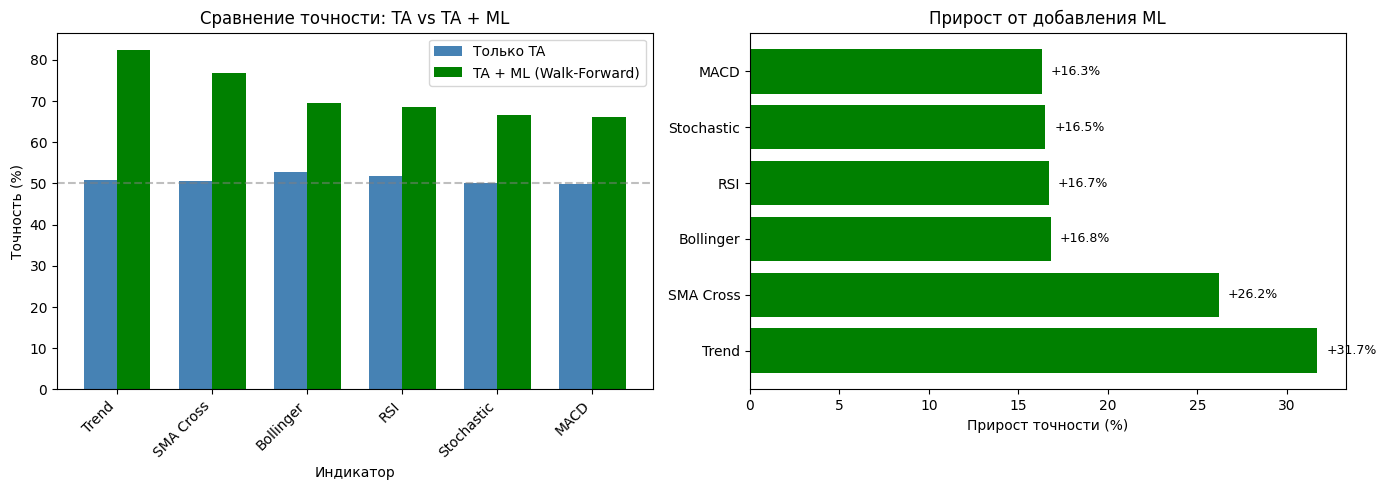

✓ График сохранён: walkforward_ta_ml_results.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение точности
ax1 = axes[0]
x = range(len(summary))
width = 0.35
bars1 = ax1.bar([i - width/2 for i in x], summary['ta_accuracy'], width, label='Только TA', color='steelblue')
bars2 = ax1.bar([i + width/2 for i in x], summary['ta_ml_accuracy'], width, label='TA + ML (Walk-Forward)', color='green')
ax1.set_xlabel('Индикатор')
ax1.set_ylabel('Точность (%)')
ax1.set_title('Сравнение точности: TA vs TA + ML')
ax1.set_xticks(x)
ax1.set_xticklabels(summary.index, rotation=45, ha='right')
ax1.legend()
ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

# График 2: Прирост
ax2 = axes[1]
colors = ['green' if x > 0 else 'red' for x in summary['improvement']]
ax2.barh(summary.index, summary['improvement'], color=colors)
ax2.set_xlabel('Прирост точности (%)')
ax2.set_title('Прирост от добавления ML')
ax2.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
for i, v in enumerate(summary['improvement']):
    ax2.text(v + 0.5, i, f'{v:+.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('walkforward_ta_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ График сохранён: walkforward_ta_ml_results.png")

## Выводы

In [15]:
# ============================================================
# Шаг 11: Расчёт Win Rate, Sharpe Ratio и кумулятивной доходности
# ============================================================

def calculate_sharpe_ratio(returns: list, risk_free_rate: float = 0.0) -> float:
    """
    Рассчитывает коэффициент Шарпа (годовой, для дневных данных)
    """
    if len(returns) < 2:
        return 0.0
    
    returns_arr = np.array(returns)
    mean_return = np.mean(returns_arr)
    std_return = np.std(returns_arr, ddof=1)
    
    if std_return == 0:
        return 0.0
    
    # Годовой Sharpe (252 торговых дня)
    sharpe = (mean_return - risk_free_rate / 252) / std_return * np.sqrt(252)
    return sharpe


def calculate_metrics(returns: list) -> dict:
    """Рассчитывает основные метрики для списка доходностей"""
    if not returns:
        return {'total': 0, 'mean': 0, 'std': 0, 'sharpe': 0, 'win_rate': 0, 'total_return': 0}
    
    returns_arr = np.array(returns)
    wins = (returns_arr > 0).sum()
    total = len(returns_arr)
    
    return {
        'total': total,
        'mean': np.mean(returns_arr) * 100,  # в процентах
        'std': np.std(returns_arr, ddof=1) * 100,  # в процентах
        'sharpe': calculate_sharpe_ratio(returns_arr),
        'win_rate': wins / total * 100 if total > 0 else 0,
        'total_return': (np.prod(1 + returns_arr) - 1) * 100 if total > 0 else 0  # кумулятивная
    }


# Рассчитываем метрики
ta_returns = [r['return'] for r in ta_only_returns]
ta_ml_returns_list = [r['return'] for r in ta_ml_returns]

ta_metrics = calculate_metrics(ta_returns)
ta_ml_metrics = calculate_metrics(ta_ml_returns_list)

print("=" * 80)
print("МЕТРИКИ: TA Only vs TA + ML")
print("=" * 80)

print(f"\n{'Метрика':<25} {'TA Only':>15} {'TA + ML':>15}")
print("-" * 55)
print(f"{'Сигналов':<25} {ta_metrics['total']:>15} {ta_ml_metrics['total']:>15}")
print(f"{'Win Rate %':<25} {ta_metrics['win_rate']:>14.1f}% {ta_ml_metrics['win_rate']:>14.1f}%")
print(f"{'Средняя доходность %':<25} {ta_metrics['mean']:>14.2f}% {ta_ml_metrics['mean']:>14.2f}%")
print(f"{'Std отклонение %':<25} {ta_metrics['std']:>14.2f}% {ta_ml_metrics['std']:>14.2f}%")
print(f"{'Sharpe Ratio':<25} {ta_metrics['sharpe']:>15.2f} {ta_ml_metrics['sharpe']:>15.2f}")
print(f"{'Кумулятивная доходность %':<25} {ta_metrics['total_return']:>14.2f}% {ta_ml_metrics['total_return']:>14.2f}%")

print("\n" + "=" * 80)
print("ИТОГОВАЯ СВОДКА (Walk-Forward + Grading)")
print("=" * 80)

if total_ta_ml > 0:
    print(f"Общая точность тех. анализа: {avg_ta:.1f}%")
    print(f"Общая точность TA + ML (Walk-Forward): {avg_ta_ml:.1f}%")
    print(f"Прирост: {avg_ta_ml - avg_ta:+.1f}%")
    
    if avg_ta_ml > avg_ta + 5:
        print("\n✅ ML значительно улучшает прогнозы!")
    elif avg_ta_ml > avg_ta:
        print("\n✅ ML даёт небольшое улучшение")
    else:
        print("\n⚠️ ML не улучшает прогнозы в данной конфигурации")
    
    # Лучший индикатор
    best_indicator = summary['improvement'].idxmax()
    best_improvement = summary['improvement'].max()
    print(f"\n🏆 Лучший индикатор: {best_indicator} (прирост: {best_improvement:+.1f}%)")
    
    # Распределение грейдов по всем тикерам
    print("\n--- Распределение грейдов ---")
    for ticker, results in all_results.items():
        total_with_grade = sum(r['total'] for r in results.values())
        if total_with_grade > 0:
            a = sum(r['grade_a'] for r in results.values())
            b = sum(r['grade_b'] for r in results.values())
            c = sum(r['grade_c'] for r in results.values())
            d = sum(r['grade_d'] for r in results.values())
            f = sum(r['grade_f'] for r in results.values())
            print(f"{ticker}: A={a} ({a/total_with_grade*100:.0f}%), B={b} ({b/total_with_grade*100:.0f}%), C={c} ({c/total_with_grade*100:.0f}%), D={d}, F={f}")
else:
    print("⚠️ Недостаточно согласованных сигналов")
    print("Попробуйте:")
    print("  1. Увеличить TRAIN_WINDOW")
    print("  2. Уменьшить порог консенсуса моделей")
    print("  3. Добавить больше моделей")

МЕТРИКИ: TA Only vs TA + ML

Метрика                           TA Only         TA + ML
-------------------------------------------------------
Сигналов                             2223             895
Win Rate %                          50.7%           70.1%
Средняя доходность %                0.04%           0.90%
Std отклонение %                    2.33%           2.39%
Sharpe Ratio                         0.29            6.00
Кумулятивная доходность %          37.54%      244453.30%

ИТОГОВАЯ СВОДКА (Walk-Forward + Grading)
Общая точность тех. анализа: 51.0%
Общая точность TA + ML (Walk-Forward): 71.6%
Прирост: +20.7%

✅ ML значительно улучшает прогнозы!

🏆 Лучший индикатор: Trend (прирост: +31.7%)

--- Распределение грейдов ---
SBER: A=203 (88%), B=27 (12%), C=0 (0%), D=0, F=0
OZON: A=235 (79%), B=60 (20%), C=3 (1%), D=0, F=0
VTBR: A=254 (69%), B=113 (31%), C=0 (0%), D=0, F=0
